# Visulization and plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn
import cv2 
import os
import shutil
from PIL import Image
import random


## Visualize the distribution of each folder

In [3]:
base_path = r"D:\Github\Deepfake_Detection\data\train"
folders = ['efs', 'fr', 'fs', 'real']
image_counts = {}

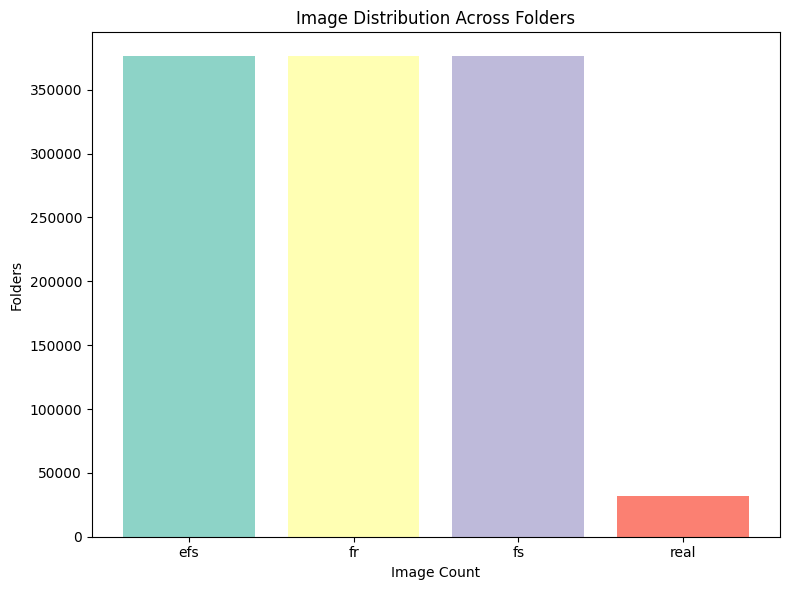

In [4]:
image_counts = {}
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    count = 0
    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                count += 1
    image_counts[folder] = count

# Sort by count
image_counts = dict(sorted(image_counts.items(), key=lambda x: x[1], reverse=True))

# Horizontal bar chart
plt.figure(figsize=(8, 6))
plt.bar(list(image_counts.keys()), list(image_counts.values()), color=plt.cm.Set3(range(len(image_counts))))

# Title and labels
plt.title("Image Distribution Across Folders")
plt.xlabel("Image Count")
plt.ylabel("Folders")

plt.tight_layout()
plt.show()

# FS generator

In [20]:
def generator_distribution_bar(base_path=r"D:\Github\Deepfake_Detection\data", target_folder=None, name=None):
    target_path = os.path.join(base_path, target_folder)

    # Count images in each subfolder
    subfolder_counts = {}
    for subfolder in os.listdir(target_path):
        subfolder_path = os.path.join(target_path, subfolder)
        if os.path.isdir(subfolder_path):
            count = sum(
                1
                for root, _, files in os.walk(subfolder_path)
                for f in files
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            )
            subfolder_counts[subfolder] = count

    # Sort by count (descending)
    subfolder_counts = dict(sorted(subfolder_counts.items(), key=lambda x: x[1], reverse=True))

    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        subfolder_counts.keys(),
        subfolder_counts.values(),
        color=plt.cm.Set3(range(len(subfolder_counts)))
    )

    # Title
    if name is None:
        name = target_folder
    ax.set_title(f"Image Distribution in '{name}' Subfolders", fontsize=16, weight="bold")

    # Axis labels
    ax.set_xlabel("Subfolders", fontsize=12)
    ax.set_ylabel("Image Count", fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

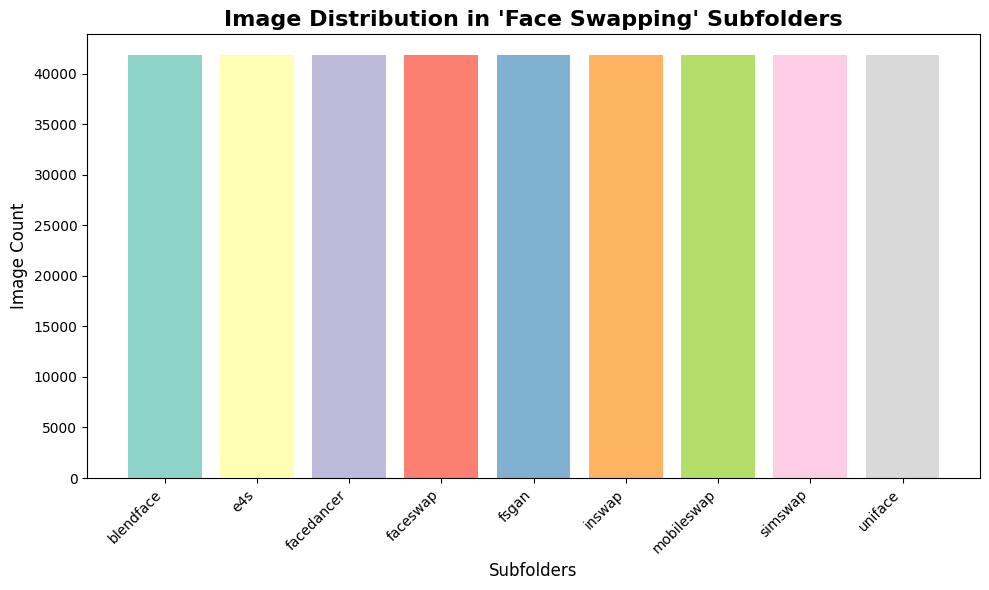

In [21]:
generator_distribution_bar(base_path = r"D:\Github\Deepfake_Detection\data" ,target_folder = 'fs', name='Face Swapping')

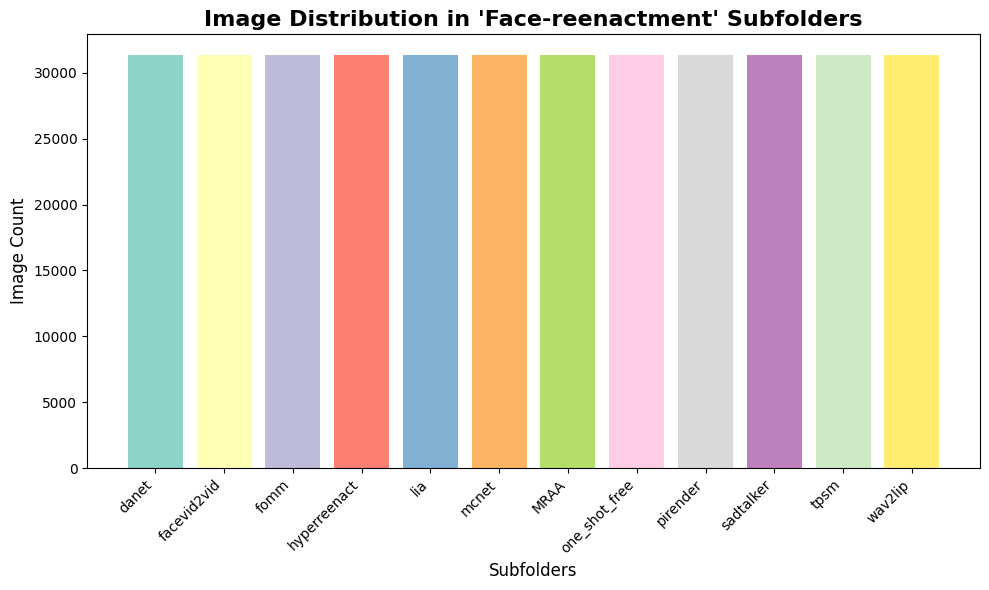

In [22]:
generator_distribution_bar(base_path = r"D:\Github\Deepfake_Detection\data" ,target_folder = 'fr', name='Face-reenactment')

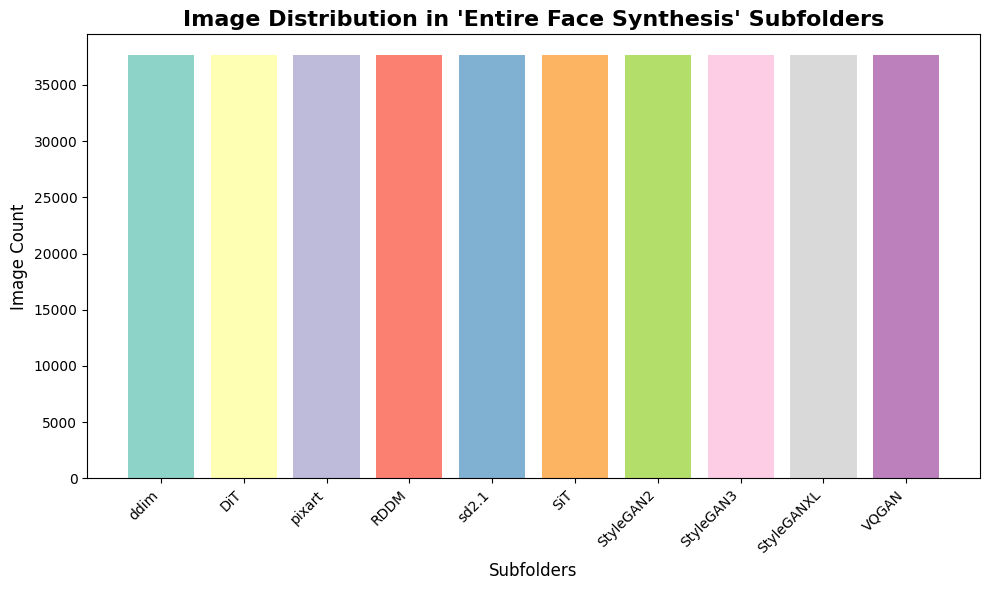

In [23]:
generator_distribution_bar(base_path = r"D:\Github\Deepfake_Detection\data" ,target_folder = 'efs', name='Entire Face Synthesis')

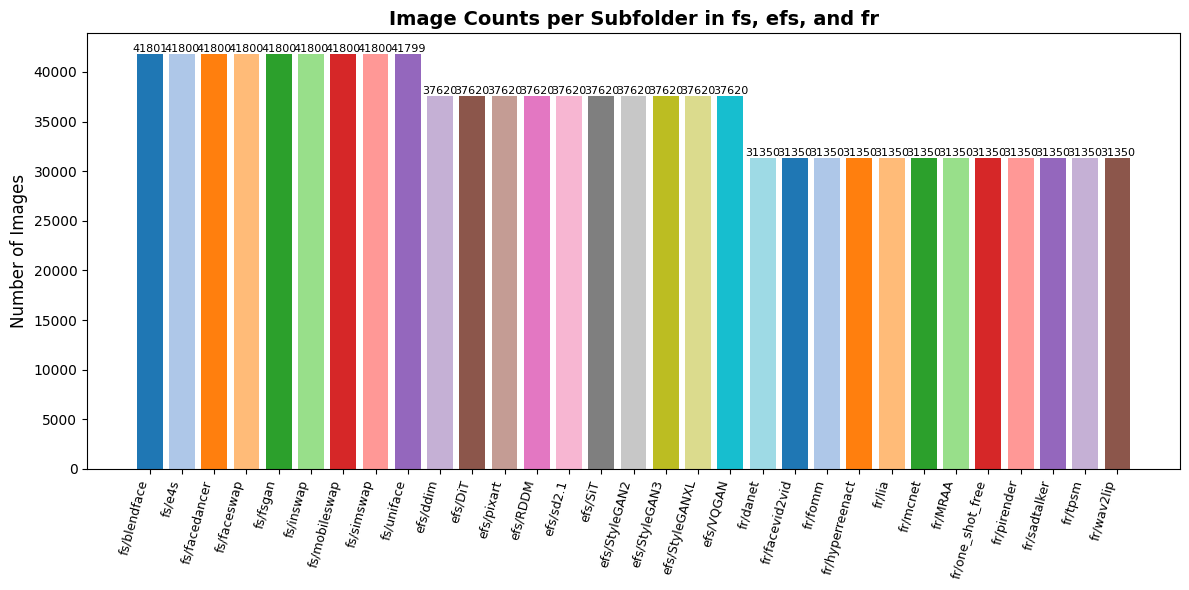

In [12]:
base_path = r"D:\Github\Deepfake_Detection\data"
folders_to_plot = ["fs", "efs", "fr"]
def get_subfolder_counts(folder_name):
    target_path = os.path.join(base_path, folder_name)
    subfolder_counts = {}
    for subfolder in os.listdir(target_path):
        subfolder_path = os.path.join(target_path, subfolder)
        if os.path.isdir(subfolder_path):
            count = sum(
                1
                for root, _, files in os.walk(subfolder_path)
                for f in files
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            )
            subfolder_counts[f"{folder_name}/{subfolder}"] = count
    return subfolder_counts

# Collect all counts
all_counts = {}
for folder in folders_to_plot:
    all_counts.update(get_subfolder_counts(folder))

# Sort by count
all_counts = dict(sorted(all_counts.items(), key=lambda x: x[1], reverse=True))

# Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(all_counts.keys(), all_counts.values(), color=plt.cm.tab20.colors)

# Rotate x labels for readability
plt.xticks(rotation=75, ha='right', fontsize=9)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Image Counts per Subfolder in fs, efs, and fr", fontsize=14, weight="bold")

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Duplicate data unitl it have the same number of image as fs/simswap

In [13]:
base_path = r"D:\Github\Deepfake_Detection\data"
target_count = 31350  # match fs/simswap

def balance_subfolder_images(folder_path):
    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    current_count = len(image_files)

    if current_count == 0:
        print(f"⚠ No images found in {folder_path}")
        return

    if current_count >= target_count:
        print(f"✅ {folder_path} already has {current_count} images (>= target)")
        return

    needed = target_count - current_count
    print(f"📈 Balancing {folder_path} — adding {needed} images")

    for i in range(needed):
        src_file = random.choice(image_files)
        name, ext = os.path.splitext(src_file)
        new_file = f"{name}_dup{i}{ext}"
        shutil.copy(os.path.join(folder_path, src_file),
                    os.path.join(folder_path, new_file))

# Loop through fs, efs, fr, and real
for main_folder in ["fs", "efs", "fr", "real"]:
    main_path = os.path.join(base_path, main_folder)
    if os.path.isdir(main_path):
        # if "real" has no subfolders, just balance it directly
        if main_folder == "real":
            balance_subfolder_images(main_path)
        else:
            for subfolder in os.listdir(main_path):
                subfolder_path = os.path.join(main_path, subfolder)
                if os.path.isdir(subfolder_path):
                    balance_subfolder_images(subfolder_path)

✅ D:\Github\Deepfake_Detection\data\fs\blendface already has 41801 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\e4s already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\facedancer already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\faceswap already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\fsgan already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\inswap already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\mobileswap already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\simswap already has 41800 images (>= target)
✅ D:\Github\Deepfake_Detection\data\fs\uniface already has 41799 images (>= target)
✅ D:\Github\Deepfake_Detection\data\efs\ddim already has 37620 images (>= target)
✅ D:\Github\Deepfake_Detection\data\efs\DiT already has 37620 images (>= target)
✅ D:\Github\Deepfake_Detection\data\efs\pixart already has 37620 images (>= tar

In [ ]:
# base_path = r"D:\Github\Deepfake_Detection\data"
# real_path = r"D:\Github\Deepfake_Detection\data\real"  # direct path to real folder
# target_count = 31350

# def balance_subfolder_images(folder_path):
#     image_files = [
#         f for f in os.listdir(folder_path)
#         if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#     ]
#     current_count = len(image_files)

#     if current_count == 0:
#         print(f"⚠ No images found in {folder_path}")
#         return

#     if current_count >= target_count:
#         print(f"✅ {folder_path} already has {current_count} images (>= target)")
#         return

#     needed = target_count - current_count
#     print(f"📈 Balancing {folder_path} — adding {needed} images")

#     for i in range(needed):
#         src_file = random.choice(image_files)
#         name, ext = os.path.splitext(src_file)
#         new_file = f"{name}_dup{i}{ext}"
#         shutil.copy(os.path.join(folder_path, src_file),
#                     os.path.join(folder_path, new_file))

# # Balance fs, efs, fr
# for main_folder in ["fs", "efs", "fr"]:
#     main_path = os.path.join(base_path, main_folder)
#     if os.path.isdir(main_path):
#         for subfolder in os.listdir(main_path):
#             subfolder_path = os.path.join(main_path, subfolder)
#             if os.path.isdir(subfolder_path):
#                 balance_subfolder_images(subfolder_path)

# # Balance real folder directly
# if os.path.isdir(real_path):
#     balance_subfolder_images(real_path)

In [5]:
import os
import random
import shutil
from collections import defaultdict

# Base directory
base_path = r"D:\Github\Deepfake_Detection\data\train"

# File extensions
extensions = ('.png', '.jpg', '.jpeg')

def count_images(folder):
    total = 0
    subfolder_counts = {}
    for root, _, files in os.walk(folder):
        img_files = [f for f in files if f.lower().endswith(extensions)]
        if img_files:
            subfolder_counts[root] = len(img_files)
            total += len(img_files)
    return total, subfolder_counts

def duplicate_images(subfolder_path, img_list, extra_needed):
    for i in range(extra_needed):
        src_file = random.choice(img_list)
        name, ext = os.path.splitext(src_file)
        new_file = f"{name}_dup{i}{ext}"
        shutil.copy(os.path.join(subfolder_path, src_file),
                    os.path.join(subfolder_path, new_file))

# Step 1: Get total images in fr
fr_total, _ = count_images(os.path.join(base_path, "fr"))

# Step 2: Process other folders
for folder in ["fs", "efs", "real"]:
    folder_path = os.path.join(base_path, folder)
    if not os.path.isdir(folder_path):
        continue

    total, sub_counts = count_images(folder_path)
    if total >= fr_total:
        print(f"✅ {folder} already has {total} images (>= fr's {fr_total})")
        continue

    needed_total = fr_total - total
    print(f"📈 Balancing {folder} — need {needed_total} more images")

    # Step 3: Even distribution across subfolders
    subfolder_list = list(sub_counts.keys())
    per_sub_needed = needed_total // len(subfolder_list)
    remainder = needed_total % len(subfolder_list)

    for idx, subfolder_path in enumerate(subfolder_list):
        img_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(extensions)]
        extra_needed = per_sub_needed + (1 if idx < remainder else 0)
        duplicate_images(subfolder_path, img_files, extra_needed)

print("✅ Duplication complete. All folders now match fr's total count.")

✅ fs already has 376200 images (>= fr's 376200)
✅ efs already has 376200 images (>= fr's 376200)
📈 Balancing real — need 344251 more images
✅ Duplication complete. All folders now match fr's total count.
